# Xenium Region Subset and Metric Calculation

This notebook subsets a Xenium spatial dataset into regions of interest, recalculates quality control metrics, and exports the subsets in a format that can be opened in Xenium Explorer.

**Example Dataset:**
- [Fresh Frozen Mouse Brain Hemisphere with 5K Mouse Pan Tissue and Pathways Panel](https://www.10xgenomics.com/datasets/xenium-prime-fresh-frozen-mouse-brain)
- Source: 10x Genomics public repository
- Note: This notebook demonstrates how to subset using one of the public Xenium datasets. You can replace it with your own data.

Note: This notebook is memory-intensive.

## Section 0 · Install Dependencies

This cell installs the core packages.

In [ ]:
!uv pip install scanpy==1.11.2  scikit-misc==0.5.1 squidpy==1.6.5 harmonypy==0.0.10 geosketch==1.3 igraph==0.11.8 pyarrow==21.0.0 datashader==0.18.2 geopandas
!uv pip install anndata==0.12.9 spatialdata[extra]==0.7.3 scanpy==1.12.0 sopa==2.2.0 numpy==2.0.2

Using Python 3.12.13 environment at: /usr
Resolved 114 packages in 70ms
Uninstalled 5 packages in 15ms
Installed 5 packages in 8ms
 - dask==2026.1.1
 + dask==2024.11.2
 - ome-zarr==0.15.0
 + ome-zarr==0.11.1
 - scanpy==1.12
 + scanpy==1.11.2
 - spatialdata==0.7.3
 + spatialdata==0.5.0
 - zarr==3.3.0
 + zarr==2.18.7
Using Python 3.12.13 environment at: /usr
Resolved 198 packages in 37ms
Uninstalled 5 packages in 7ms
Installed 5 packages in 10ms
 - dask==2024.11.2
 + dask==2026.1.1
 - ome-zarr==0.11.1
 + ome-zarr==0.15.0
 - scanpy==1.11.2
 + scanpy==1.12
 - spatialdata==0.5.0
 + spatialdata==0.7.3
 - zarr==2.18.7
 + zarr==3.3.0


## Section 1 · Imports & Setup

Load all required Python libraries and configure paths to the data.

In [ ]:
import spatialdata as sd
import spatialdata_io
import sopa.io.explorer
import xarray as xr
from spatialdata.models import Image2DModel
import spatialdata
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import json
import os
import warnings

warnings.filterwarnings("ignore")


## Section 2 · Load Xenium Data Using SpatialData

### Section 2.1 · Download the Xenium Dataset from the 10x Site

In [ ]:
# Load Xenium data as spatialdata
!wget https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Mouse_Brain_Coronal_FF/Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip
!unzip Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip -d Xenium_bundle_output
!rm Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip

--2026-08-06 19:39:41--  https://cf.10xgenomics.com/samples/xenium/3.0.0/Xenium_Prime_Mouse_Brain_Coronal_FF/Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip
Resolving cf.10xgenomics.com (cf.10xgenomics.com)... 104.18.1.173, 104.18.0.173, 2606:4700::6812:ad, ...
Connecting to cf.10xgenomics.com (cf.10xgenomics.com)|104.18.1.173|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13315451681 (12G) [application/zip]
Saving to: ‘Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip’

Xenium_Prime_Mouse_ 100%[===================>]  12.40G  23.0MB/s    in 10m 53s 

2026-08-06 19:50:36 (19.4 MB/s) - ‘Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip’ saved [13315451681/13315451681]

Archive:  Xenium_Prime_Mouse_Brain_Coronal_FF_outs.zip
  inflating: Xenium_bundle_output/analysis_summary.html  
 extracting: Xenium_bundle_output/analysis.zarr.zip  
  inflating: Xenium_bundle_output/cell_boundaries.csv.gz  
  inflating: Xenium_bundle_output/cell_boundaries.parquet  
  inflating: Xenium_bund

In [ ]:
# Convert Xenium output bundle into a SpatialData object
sdata = spatialdata_io.xenium("Xenium_bundle_output")

In [ ]:
# Check for SpatialData object
sdata

SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 23912, 34154), (4, 11956, 17077), (4, 5978, 8538), (4, 2989, 4269), (4, 1494, 2134)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
│     └── 'nucleus_labels': DataTree[yx] (23912, 34154), (11956, 17077), (5978, 8538), (2989, 4269), (1494, 2134)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (63173, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (63060, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (63173, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

### Section 2.3 · Select region of interest in Xenium Explorer and export its GeoJSON file

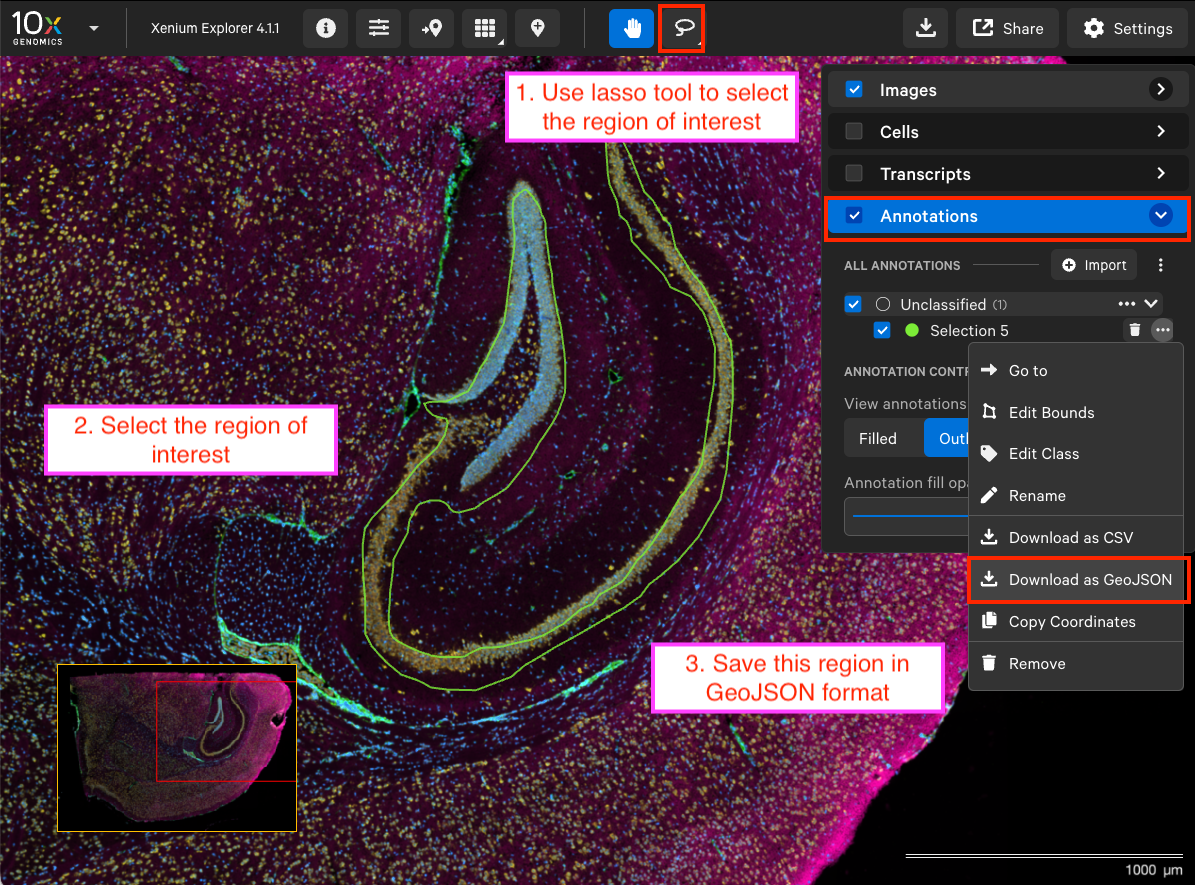

## Section 3 · Define the Subsetting Function

The function below cuts the full dataset down to a region of interest defined by a polygon drawn in Xenium Explorer (saved as a GeoJSON file).

**What is polygon_query?**

`polygon_query` is a SpatialData function that performs a spatial subset. It takes the full dataset and a polygon boundary (geoJSON file), then keeps only the data that falls within that boundary:

- Cells — only cells whose centroid is inside the polygon

- Transcripts — only transcript points inside the polygon

- Cell boundaries — only the boundary shapes that intersect the polygon

The result is a smaller SpatialData object containing just the region you selected.

Note: `polygon_query` does not clip the morphology images — they remain full-size, which is why Explorer may show a larger area than your subset when you open it.

Here is what it does step by step:

1. **Reads the polygon** from the GeoJSON file
2. **Queries the dataset** — keeps only cells, transcripts, and boundaries that fall inside the polygon
3. **Harmonizes cell IDs** — removes any cells that don't appear in both the cell table and the cell boundary shapes, so they stay consistent

In [ ]:
def subset_region(sdata, polygon_path: str, label: str):
    """
    Subset sdata to the region defined by polygon_path.
    Returns the subsetted SpatialData object.
    """

    # Step 1 — load the polygon
    print(f"[{label}] Reading polygon: {polygon_path}")
    polygon_geom = gpd.read_file(polygon_path)

    # Step 2 — spatial query
    print(f"[{label}] Querying spatial data...")
    query_sdata = spatialdata.polygon_query(
        sdata,
        polygon=polygon_geom.geometry[0],
        target_coordinate_system="global",
    )

    # Step 3 — re-link table to cell_boundaries and harmonise cell IDs
    query_sdata["table"].obs["region"] = "cell_boundaries"
    query_sdata.set_table_annotates_spatialelement(
        "table", region="cell_boundaries", instance_key="cell_id"
    )
    cells_in_table    = query_sdata["table"].obs["cell_id"].values
    cells_in_boundary = query_sdata["cell_boundaries"].index.values
    common_ids = pd.Index(cells_in_table).intersection(pd.Index(cells_in_boundary))
    query_sdata["table"] = query_sdata["table"][
        query_sdata["table"].obs["cell_id"].isin(common_ids)
    ].copy()
    query_sdata["cell_boundaries"] = query_sdata["cell_boundaries"].loc[common_ids]

    print(f"[{label}] Cells after harmonisation: {query_sdata['table'].n_obs:,}")
    print(f"[{label}] Done.")
    return query_sdata


print("subset_region() defined.")

subset_region() defined.


## Section 4 · Subset the Hippocampus

In [ ]:
# Load GeoJSON file
# This file is obtained from Section 2.3. If using your own file, upload it to the current directory.
!wget https://github.com/10XGenomics/analysis_guides/blob/main/files/hippocampus.geojson

In [ ]:
# Note: Depending on the size of your ROI, this step is the most memory-intensive and may take some time to run.
sdata_hippo = subset_region(sdata, polygon_path = "hippocampus.geojson", label = 'Xenium_bundle_output'+"Hippocampus Subset")
sdata_hippo

[Xenium_bundle_outputHippocampus Subset] Reading polygon: hippocampus.geojson
[Xenium_bundle_outputHippocampus Subset] Querying spatial data...
[Xenium_bundle_outputHippocampus Subset] Cells after harmonisation: 3,543
[Xenium_bundle_outputHippocampus Subset] Done.


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 9859, 6285), (4, 4929, 3142), (4, 2465, 1571), (4, 1233, 786), (4, 616, 393)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (9859, 6285), (4929, 3142), (2465, 1571), (1233, 786), (616, 393)
│     └── 'nucleus_labels': DataTree[yx] (9859, 6285), (4929, 3142), (2465, 1571), (1233, 786), (616, 393)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 13) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (3543, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (3485, 2) (2D shapes)
└── Tables
      └── 'table': AnnData (3543, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), nucleus_boundaries (Shapes)

Save the subsetted hippocampus data as a Zarr file

In [ ]:
sdata_hippo.write("sdata_hippo.zarr")

Optional: compress the hippocampus Zarr store for transfer or backup.

In [ ]:
 ! zip -r sdata_hippo.zarr.zip sdata_hippo.zarr/

  adding: sdata_hippo.zarr/ (stored 0%)
  adding: sdata_hippo.zarr/images/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/1/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/1/0/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/1/0/0 (deflated 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/0/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/0/0/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/0/0/0 (deflated 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/3/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/3/0/ (stored 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4/c/3/0/0 (deflated 0%)
  adding: sdata_hippo.zarr/images/morphology_focus/s4

## Section 6 · Recalculate Metrics for the Subsetted Data

First a function is defined which calculates four quality control metrics for a given subset. These metrics are the same as what is in the analysis summary:

- **Number of cells**
- **Median transcripts per cell**
- **Nuclear transcripts per 100 µm²**
- **Total high-quality transcripts**


In [ ]:
# 1. First get the total number of cells from eachdataset, this is the number of observations from the table
num_cells_hippo = sdata_hippo["table"].n_obs

Calculate the median transcript count per cell (excluding zero-count cells) for each subset.

In [ ]:
# 2. Calculate the Median transcripts per cell (zero-count cells excluded)

# First we extract the transcipt counts from the table
counts_hippo = sdata_hippo["table"].obs["transcript_counts"]

# Next we calculate the median of the counts, and exclude any transcripts with 0 counts
median_tx_hippo = float(counts_hippo[counts_hippo > 0].median())

Calculate nuclear transcripts per 100 µm² of tissue area in the hippocampus subset, restricted to high-quality (QV ≥ 20) transcripts located within the nucleus.

In [ ]:
# 3. Nuclear transcripts per 100 µm² Hippocampus
#Repaeting the previous step
true_genes_hippo = sdata_hippo["table"].var[
    sdata_hippo["table"].var["feature_types"] == "Gene Expression"
  ].index
tx_hippo = sdata_hippo["transcripts"]
nuclear_tx_hippo = len(
        tx_hippo[
            (tx_hippo["qv"] >= 20.0) &
            tx_hippo["feature_name"].isin(true_genes_hippo) &
            (tx_hippo["overlaps_nucleus"] == 1)
        ].compute()
    )

#Next we extract the total nucleus area from the table
total_nuclear_area_hippo = sdata_hippo["table"].obs["nucleus_area"].sum()
#Lastly, we calculate the amount of trancripts nuclear transcripts per 100 µm² area
nuclear_tx_per_100_hippo = (nuclear_tx_hippo / total_nuclear_area_hippo) * 100

Count the total number of high-quality transcripts (QV ≥ 20) in each subset.

In [ ]:
 # 4. Total high-quality transcripts (QV >= 20)
 # The final QC metric is to calculate the number of high quality transcripts
 # This is done filtering the transcripts based on a quality score (qv) of 20, then taking the length for the total transcripts
num_high_qv_hippo = len(
    sdata_hippo.points["transcripts"][
        sdata_hippo.points["transcripts"]["qv"] >= 20
    ].compute()
)

### Section 6.1 · Visualize the Metrics in a Table

In [ ]:
# Visualize the calculated metrics for each subset as a table
comparison = pd.DataFrame(
    {
        "Metric": [
            "Number of cells",
            "Median transcripts / cell",
            "Nuclear tx / 100 µm²",
            "Total high-QV transcripts (QV≥20)",
        ],
        "Hipocampus": [
            num_cells_hippo,
            round(median_tx_hippo, 1),
            round(nuclear_tx_per_100_hippo, 1),
            num_high_qv_hippo,
        ],
    }
).set_index("Metric")

comparison

,Hipocampus
Metric,
Number of cells,3543.0
Median transcripts / cell,1371.0
Nuclear tx / 100 µm²,1565.9
Total high-QV transcripts (QV≥20),6471365.0


The table counts the four QC metrics for the hippocampus subset.

We can also further explore the "Percent of Transcripts within Cells" in Each Subset, by re-calculating this metric for each region.

In [ ]:
# Calculate Percent of Transcripts within Cells for the Hippocampus Subset
# Get all high-QV transcripts for hippocampus
all_high_qv_hippo = len(
    sdata_hippo.points["transcripts"][
        sdata_hippo.points["transcripts"]["qv"] >= 20
    ].compute()
)

# Get transcripts counted in cells = sum of expression matrix
transcripts_in_cells_hippo = int(sdata_hippo["table"].X.sum())

#Divide all high qv transcripts by transcripts only found in cells
percent_in_cells_hippo = (transcripts_in_cells_hippo / all_high_qv_hippo) * 100

#print the result and round the percentage to 1 decimal
print(f"  Percent transcripts in hippocampus cells: {percent_in_cells_hippo:.1f}%")

  Percent transcripts in hippocampus cells: 82.0%


## Section 7 · Export Each Subset to Xenium Explorer

The follwing code is part of sopa package, more information can be found here: https://github.com/prism-oncology/sopa. The `export_to_explorer` function writes a subsetted region to a format that can be opened dirctly in Xenium Explorer and updates the experiment metadata with the correct cell and transcript counts.

### Section 7.1 · Export the Hippocampus Subset

In [ ]:
# Set the output folder
output_hippo = "Hippo_XE"

Create the output directory for the Xenium Explorer-formatted hippocampus data.

In [ ]:
# Make the output directory
import os
os.makedirs(output_hippo, exist_ok=True)

Write the hippocampus subset to Xenium Explorer format using `sopa`.

In [ ]:
# write the subset to Xenium Explorer format
sopa.io.explorer.write(output_hippo, sdata_hippo, shapes_key="cell_boundaries")

[INFO] (sopa.io.explorer.table) Writing table with 5006 columns
[INFO] (sopa.io.explorer.table) Writing 2 cell/observations categories: segmentation_method, region
[INFO] (sopa.io.explorer.shapes) Writing 3543 cell polygons
[INFO] (sopa.io.explorer.points) Writing 8870951 transcripts
[INFO] (sopa.io.explorer.points)    > Level 0: 8870951 transcripts
[INFO] (sopa.io.explorer.points)    > Level 1: 2217737 transcripts
[INFO] (sopa.io.explorer.points)    > Level 2: 554434 transcripts
[INFO] (sopa.io.explorer.points)    > Level 3: 138608 transcripts
[INFO] (sopa.io.explorer.points)    > Level 4: 34652 transcripts
[INFO] (sopa.io.explorer.images) Writing multiscale image with procedure=semi-lazy (load in memory when possible)
[INFO] (sopa.io.explorer.images)    (Loading image of shape (4, 9859, 6285)) in memory
[INFO] (sopa.io.explorer.images)    > Image of shape (4, 9859, 6285)
[INFO] (sopa.io.explorer.images)    > Image of shape (4, 4929, 3142)
[INFO] (sopa.io.explorer.images)    > Image o

Update the experiment metadata file so the reported cell and transcript counts match the subsetted data.

In [ ]:
# Update the experiment.xenium metadata file to make sure number of cells nd transcripts matches the subset
import json

target_xenium_path = os.path.join(output_hippo, "experiment.xenium")

# Read the existing metadata file that sopa created
with open(target_xenium_path) as f:
    target_data = json.load(f)

# Update with correct cell and transcript counts
num_cells_after_filter = int((sdata_hippo["table"].obs["transcript_counts"]>0).sum())
target_data["num_cells"] = num_cells_after_filter
target_data["transcripts_per_cell"] = float(np.mean(sdata_hippo["table"].X.sum(axis=1)))
target_data["num_transcripts"] = float(sdata_hippo["table"].X.sum())
target_data["num_transcripts_high_qv"] = len(
    sdata_hippo.points["transcripts"][
        sdata_hippo.points["transcripts"]["qv"] >= 20
    ].compute()
)

# Write the updated metadata back to the file
with open(target_xenium_path, "w") as f:
    json.dump(target_data, f, indent=4)

print("experiment.xenium metadata updated")
print(f"  - Cells: {target_data['num_cells']:,}")
print(f"  - Transcripts: {target_data['num_transcripts']:,.0f}")

experiment.xenium metadata updated
  - Cells: 3,543
  - Transcripts: 5,309,343


Compress the exported hippocampus Xenium Explorer bundle for download.

In [ ]:
!zip -r Hippo_XE.zip Hippo_XE/

  adding: Hippo_XE/ (stored 0%)
  adding: Hippo_XE/analysis.zarr.zip (stored 0%)
  adding: Hippo_XE/transcripts.zarr.zip (stored 0%)
  adding: Hippo_XE/cell_feature_matrix.zarr.zip (stored 0%)
  adding: Hippo_XE/morphology.ome.tif (deflated 0%)
  adding: Hippo_XE/experiment.xenium (deflated 64%)
  adding: Hippo_XE/cells.zarr.zip (stored 0%)


Now you can open the saved subregion in Xenium Explorer.

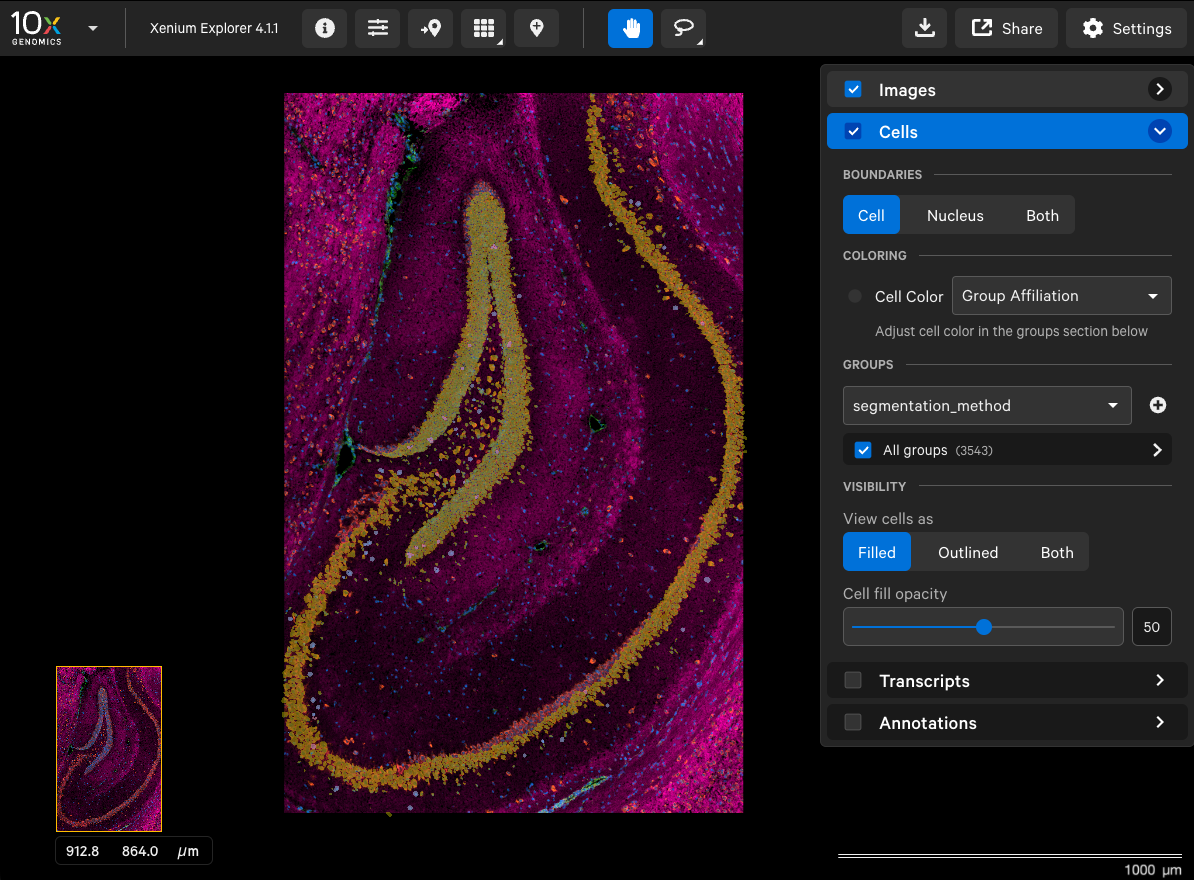